In [2]:
%load_ext autoreload
%autoreload 2
from kg.cleaning.referencing.spacy_pipeline_patent import PipelineBuilder, EntityMapper # Adjust import as needed
from PyPDF2 import PdfReader
import os
import amrlib
import penman
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch
from amrlib import load_stog_model
import networkx as nx
import sys, os
from pyvis.network import Network
import os
import json
import xml.etree.ElementTree as ET

import epo_ops
import spacy
from dotenv import load_dotenv
from PatentProvider import PatentProvider
import random
import os
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import json
import json
import random
import os
import spacy
from spacy.tokens import DocBin
import torch
import matplotlib.pyplot as plt
import amrlib
import spacy
from tools.sentence.sentence import Sentence
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from kg.formatting.formatting_manager import FormattingManager
import sys, importlib,os
sys.modules.pop('PatentTextFormatter', None)
importlib.invalidate_caches()
import numpy as np
from kg.cleaning.normalising.word_normaliser import WordNormaliser
from fastcoref import FCoref
import kg.cleaning.referencing.spacy_pipeline_patent
from tools.sentence.entity import Entity
import torch, os, platform
from kg.generating_kg.generating.NodeGenerator import NodeGenerator
import spacy
import os, pyvis, jinja2, sys
import epo_ops
import epo_ops
import os
import spacy
import xml.etree.ElementTree as ET
import json
import sys
from kg.generating_kg.analysing.TextEncoder import TextEncoder
from PatentProvider import PatentProvider

c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
12/22/2025 16:50:54 - INFO - 	 Loading faiss with AVX512 support.
12/22/2025 16:50:54 - INFO - 	 Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
12/22/2025 16:50:54 - INFO - 	 Loading faiss with AVX2 support.
12/22/2025 16:50:54 - INFO - 	 Successfully loaded faiss with AVX2 support.


In [4]:
import torch

if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.5)  # 50% of VRAM


In [ ]:
nlp = spacy.load("en_core_web_trf")   # see optimization ideas below
formatterManager = FormattingManager()
random_description = PatentProvider().getDescription("1502502")
doc = nlp(random_description)
sentences = [sent.text.strip() for sent in doc.sents]  # keep if you need list later
sentence_split = []
def process_sentence(s):
    return formatterManager.split(s)
with ThreadPoolExecutor(max_workers=5) as ex:
    for result in ex.map(process_sentence, sentences):
        sentence_split.extend(result)
print(sentence_split)


obP7iHGVo6HMzenhj3uXdl8T7E7zGPpVGhcRDthgmf6rzZmd


HTTPError: 404 Client Error: Not Found for url: https://ops.epo.org/3.2/rest-services/published-data/publication/docdb/description

In [6]:

model_path = "training/info/done/hf/sentence_classifier_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

id2label = model.config.id2label

def classify_sentence(text: str):#
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=-1)[0]
    pred_id = int(torch.argmax(probs))
    return id2label[pred_id], probs.tolist()

# Example: filter sentences.txtss
for sentence in sentence_split:

    text = sentence.text
    label_name, probs = classify_sentence(text)
    if label_name != "INFORMATIVE":
        sentence_split.remove(sentence)



In [7]:
from typing import Callable

def debug_component_crash(pipeline_builder, sentence_split, sep=" "):
    nlp = pipeline_builder.nlp
    joined_text = sep.join(s.text for s in sentence_split)

    print("Joined chars:", len(joined_text))
    print("Pipeline:", nlp.pipe_names)

    # Build a Doc without running the full pipeline
    doc = nlp.make_doc(joined_text)
    print("make_doc ok. Tokens:", len(doc))

    def run_pipe(pipe_name: str, doc_in):
        pipe = nlp.get_pipe(pipe_name)
        return pipe(doc_in)

    # If you have a HF tokenizer in ner, measure tokens for the joined text
    if "ner" in nlp.pipe_names:
        try:
            ner_pipe = nlp.get_pipe("ner")
            tok = getattr(ner_pipe, "tokenizer", None) or getattr(getattr(ner_pipe, "ner", None), "tokenizer", None)
            if tok is not None:
                ids = tok(joined_text, truncation=False, add_special_tokens=True)["input_ids"]
                print("NER tokenizer tokens:", len(ids))
                print("NER tokenizer model_max_length:", getattr(tok, "model_max_length", None))
        except Exception as e:
            print("Token count probe failed:", repr(e))

    # Run sequentially through the pipeline and stop at the first failing component
    current = doc
    for name in nlp.pipe_names:
        try:
            current = run_pipe(name, current)
            ents = len(getattr(current, "ents", []))
            clusters = getattr(current._, "coref_clusters", None)
            n_clusters = len(clusters) if isinstance(clusters, list) else None
            print(f"✅ {name} ok | ents={ents} | coref_clusters={n_clusters}")
        except Exception as e:
            print(f"\n❌ CRASH in component: {name}")
            print("Error:", repr(e))
            # show a small hint about size
            print("Doc length tokens (spaCy):", len(current))
            print("Joined preview:", repr(joined_text[:300]))
            return name, e

    print("\n✅ No component crashed on joined text")
    return None, None
pipeline_builder = PipelineBuilder()
bad_pipe, err = debug_component_crash(pipeline_builder, sentence_split, sep=" ")
print("Bad pipe:", bad_pipe)


Device set to use cpu
12/22/2025 16:53:10 - INFO - 	 missing_keys: []
12/22/2025 16:53:10 - INFO - 	 unexpected_keys: []
12/22/2025 16:53:10 - INFO - 	 mismatched_keys: []
12/22/2025 16:53:10 - INFO - 	 error_msgs: []
12/22/2025 16:53:10 - INFO - 	 Model Parameters: 590.0M, Transformer: 434.6M, Coref head: 155.4M


Joined chars: 34830
Pipeline: ['sentencizer', 'tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'entity_normaliser', 'windowed_fastcoref', 'local_entity_linker']
make_doc ok. Tokens: 6432
NER tokenizer tokens: 6558
NER tokenizer model_max_length: 1000000000000000019884624838656
✅ sentencizer ok | ents=0 | coref_clusters=0
✅ tok2vec ok | ents=0 | coref_clusters=0
✅ tagger ok | ents=0 | coref_clusters=0
✅ parser ok | ents=0 | coref_clusters=0
✅ attribute_ruler ok | ents=0 | coref_clusters=0
✅ lemmatizer ok | ents=0 | coref_clusters=0


KeyboardInterrupt: 

In [8]:
from dataclasses import dataclass
from typing import List

@dataclass(frozen=True)
class JoinedText:
    """
    Holds the concatenated text passed to spaCy
    and the starting character offset of each sentence.
    """
    text: str
    starts: List[int]


def join_sentences(sentences, sep=" "):
    """
    Join a list of Sentence objects into one string while
    tracking sentence start offsets.

    Args:
        sentences: List of Sentence objects with `.text`
        sep: Separator inserted between sentences (default: space)

    Returns:
        JoinedText(text, starts)
    """
    parts = []
    starts = []
    cur = 0

    for i, s in enumerate(sentences):
        starts.append(cur)
        parts.append(s.text)
        cur += len(s.text)

        if i < len(sentences) - 1:
            parts.append(sep)
            cur += len(sep)

    return JoinedText("".join(parts), starts)


In [9]:
pipeline_builder = PipelineBuilder()
entity_mapper = EntityMapper(sentence_cls=Sentence)

joined = join_sentences(sentence_split, sep=" ")
doc = pipeline_builder.nlp(joined.text)

clusters = entity_mapper.map_to_sentences(doc, sentence_split, joined)

print("doc.ents:", len(doc.ents))
print("coref clusters:", len(doc._.coref_clusters))
print("entities in first sentence:", len(sentence_split[0].entities))


12/22/2025 16:53:27 - INFO - 	 missing_keys: []
12/22/2025 16:53:27 - INFO - 	 unexpected_keys: []
12/22/2025 16:53:27 - INFO - 	 mismatched_keys: []
12/22/2025 16:53:27 - INFO - 	 error_msgs: []
12/22/2025 16:53:27 - INFO - 	 Model Parameters: 590.0M, Transformer: 434.6M, Coref head: 155.4M
12/22/2025 16:54:02 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 23.75 examples/s]
12/22/2025 16:54:02 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:06<00:00,  6.83s/it]
12/22/2025 16:54:09 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 55.64 examples/s]
12/22/2025 16:54:09 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:05<00:00,  5.49s/it]
12/22/2025 16:54:14 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 48.30 examples/s]
12/22/2025 16:54:14 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:05<00:00,  

doc.ents: 1546
coref clusters: 0
entities in first sentence: 2


In [10]:
print(sentence_split)

[Sentence(text='The present invention relates to a display device.', index=0, source='', span=None, id='955a4b19-077a-49de-9254-ed1380292ebd', kg_node_id=None, embedding=None, tokens=[], entities={(0, 21): Entity(The present invention), (35, 49): Entity(display device)}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regarding pseudo space.', index=1, source='', span=None, id='4129d8bf-dbd7-45d8-ae1b-9ad3c6ac7a6c', kg_node_id=None, embedding=None, tokens=[], entities={(4, 18): Entity(display device), (26, 38): Entity(appreciation), (49, 61): Entity(pseudo space)}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The display device is for appreciation regarding creatures and/or objects which float in the air.', index=3, source='', span=None, id='41826252-5328-46aa-88a5-e8718604eeb8', kg_node_id=None, embedding=None, tokens=[], entities={(4, 18): Entity(display device), (26, 38)

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
import threading
from typing import Any

triples = []

def sentence_entities_to_llm_inventory(sentence_obj) -> list[dict]:
    inv = []
    for (start, end), ent in sorted(sentence_obj.entities.items(), key=lambda kv: kv[0][0]):
        inv.append({
            "id": ent.ref,              # stable kb id
            "label": ent.label,
            "span": [start, end],
            "text": ent.name,
            "ref_short": getattr(ent, "ref_short", None),
        })
    return inv


# --- Thread-safe NodeGenerator creation (recommended) ---
_thread_local = threading.local()

def get_node_gen():
    if not hasattr(_thread_local, "node_gen"):
        _thread_local.node_gen = NodeGenerator()
    return _thread_local.node_gen


def normalize_triples(result: Any) -> list[dict]:
    """
    Make output robust across different NodeGeneratorAgent return types.
    We want: list[{"head":..., "relation":..., "tail":...}, ...]
    """
    if result is None:
        return []

    # Already parsed
    if isinstance(result, list):
        return [t for t in result if isinstance(t, dict)]

    # Some agents return dict like {"triples":[...]}
    if isinstance(result, dict):
        if "triples" in result and isinstance(result["triples"], list):
            return [t for t in result["triples"] if isinstance(t, dict)]
        return []

    # String -> try parse JSON (strip common markdown fences)
    if isinstance(result, str):
        s = result.strip()
        if s.startswith("```"):
            # remove ```json ... ``` fences
            s = s.strip("`")
            # sometimes includes leading "json\n"
            s = s.replace("json\n", "", 1).strip()

        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [t for t in parsed if isinstance(t, dict)]
            if isinstance(parsed, dict) and "triples" in parsed:
                return [t for t in parsed["triples"] if isinstance(t, dict)]
        except Exception:
            return []

    return []


def process_sentence(sent):
    entities = sentence_entities_to_llm_inventory(sent)
    node_gen = get_node_gen()  # thread-local instance

    # IMPORTANT: NodeGenerator.run must accept sentence + entities
    result = node_gen.run(sent.text, entities)

    return normalize_triples(result)


MAX_WORKERS = 8
for i in sentence_split:
    print(i.text, "->", [e.name for e in i.entities.values()])

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {executor.submit(process_sentence, s): idx for idx, s in enumerate(sentence_split)}

    for future in as_completed(future_to_idx):
        idx = future_to_idx[future]
        try:
            result = future.result()
            triples.extend(result)
        except Exception as e:
            print(f"Error on sentence {idx}: {e}")

print(triples)


12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:11 - INFO - 	 AFC is enabled with max remote calls: 10.


The present invention relates to a display device. -> ['The present invention', 'display device']
The display device is for appreciation regarding pseudo space. -> ['display device', 'appreciation', 'pseudo space']
The display device is for appreciation regarding creatures and/or objects which float in the air. -> ['display device', 'appreciation', 'creatures', 'objects', 'float in the air']
Recently, for a purpose of refreshing feelings of residents and the like indoors, interiors with motifs in the water are provided at homes or in the offices. -> ['refreshing feelings of', 'residents', 'indoors', 'interiors', 'motifs in the', 'water', 'homes', 'offices']
Recently, for a purpose of refreshing feelings of residents and the like indoors, interiors with motifs in the air are provided at homes or in the offices. -> ['refreshing feelings of', 'residents', 'indoors', 'interiors', 'motifs in the air', 'homes', 'offices']
Examples of interiors with motifs in the water include aquariums. -> [

12/22/2025 16:56:12 - INFO - 	 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 200 OK"
12/22/2025 16:56:12 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:12 - INFO - 	 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 200 OK"
12/22/2025 16:56:12 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:12 - INFO - 	 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 200 OK"
12/22/2025 16:56:12 - INFO - 	 AFC is enabled with max remote calls: 10.


RAW: ```json
[{"head":"ent::invention::5f95db","relation":"relates to","tail":"ent::device::d61489"}]
```
CONTENT: [{'head': 'ent::invention::5f95db', 'relation': 'relates to', 'tail': 'ent::device::d61489'}]
sentence: Aquariums keep aquatic animals such as tropical fish and the like. [{'id': 'ent::aquarium::7ebc81', 'label': 'HARDWARE', 'span': [0, 9], 'text': 'Aquariums', 'ref_short': 'bc81'}, {'id': 'ent::animal::a587b9', 'label': 'BIOMOLECULE', 'span': [15, 30], 'text': 'aquatic animals', 'ref_short': '87b9'}, {'id': 'ent::fish::6e0d7d', 'label': 'BIOMOLECULE', 'span': [39, 52], 'text': 'tropical fish', 'ref_short': '0d7d'}, {'id': 'ent::like::1ea077', 'label': 'UNCLASSIFIED_ENTITY', 'span': [57, 65], 'text': 'the like', 'ref_short': 'a077'}]
RAW: ```json
[
  {
    "head": "ent::device::d61489",
    "relation": "is for appreciation regarding",
    "tail": "ent::space::c65340"
  }
]
```
CONTENT: [{'head': 'ent::device::d61489', 'relation': 'is for appreciation regarding', 'tail': 'e

12/22/2025 16:56:12 - INFO - 	 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 200 OK"
12/22/2025 16:56:12 - INFO - 	 AFC is enabled with max remote calls: 10.
12/22/2025 16:56:12 - INFO - 	 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 200 OK"
12/22/2025 16:56:12 - INFO - 	 AFC is enabled with max remote calls: 10.


...

RAW: ```json
[
  {
    "head": "ent::tank::e57f43",
    "relation": "for appreciation of",
    "tail": "ent::invention::5f95db"
  },
  {
    "head": "ent::tank::e57f43",
    "relation": "is used as",
    "tail": "ent::aquarium::7ebc81"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "of",
    "tail": "ent::model::f62b94"
  }
]
```
CONTENT: [{'head': 'ent::tank::e57f43', 'relation': 'for appreciation of', 'tail': 'ent::invention::5f95db'}, {'head': 'ent::tank::e57f43', 'relation': 'is used as', 'tail': 'ent::aquarium::7ebc81'}, {'head': 'ent::display::8b8fa2', 'relation': 'of', 'tail': 'ent::model::f62b94'}]


12/22/2025 16:56:55 - INFO - 	 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 200 OK"


RAW: ```json
[
  {
    "head": "ent::display::8b8fa2",
    "relation": "can be provided without",
    "tail": "ent::behavior::96f9fc"
  },
  {
    "head": "ent::behavior::96f9fc",
    "relation": "such as",
    "tail": "ent::imbalance::85048d"
  },
  {
    "head": "ent::imbalance::85048d",
    "relation": "due to",
    "tail": "ent::adhesion::28f2dd"
  },
  {
    "head": "ent::adhesion::28f2dd",
    "relation": "of",
    "tail": "ent::bubble::4f402d"
  },
  {
    "head": "ent::bubble::4f402d",
    "relation": "to",
    "tail": "ent::model::f62b94"
  }
]
```
CONTENT: [{'head': 'ent::display::8b8fa2', 'relation': 'can be provided without', 'tail': 'ent::behavior::96f9fc'}, {'head': 'ent::behavior::96f9fc', 'relation': 'such as', 'tail': 'ent::imbalance::85048d'}, {'head': 'ent::imbalance::85048d', 'relation': 'due to', 'tail': 'ent::adhesion::28f2dd'}, {'head': 'ent::adhesion::28f2dd', 'relation': 'of', 'tail': 'ent::bubble::4f402d'}, {'head': 'ent::bubble::4f402d', 'relation': 'to', 'ta

12/22/2025 16:56:57 - INFO - 	 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash-lite:generateContent "HTTP/1.1 200 OK"


RAW: ```json
[
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "tail": "ent::creature::837b88"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "tail": "ent::object::6ff1b8"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "tail": "ent::fish::6e0d7d"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "tail": "ent::submarine::9d90af"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "tail": "ent::spaceship::42d542"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "tail": "ent::airship::31e188"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "tail": "ent::butterfly::75e02b"
  },
  {
    "head": "ent::display::8b8fa2",
    "relation": "is also available regarding",
    "t

In [12]:
print(triples)

[{'head': 'ent::invention::5f95db', 'relation': 'relates to', 'tail': 'ent::device::d61489'}, {'head': 'ent::device::d61489', 'relation': 'is for appreciation regarding', 'tail': 'ent::space::c65340'}, {'head': 'ent::device::d61489', 'relation': 'is for appreciation regarding', 'tail': 'ent::creature::837b88'}, {'head': 'ent::device::d61489', 'relation': 'is for appreciation regarding', 'tail': 'ent::object::6ff1b8'}, {'head': 'ent::feeling::6c7c6c', 'relation': 'refreshing feelings of', 'tail': 'ent::resident::2feb50'}, {'head': 'ent::interior::38a5ed', 'relation': 'with motifs in', 'tail': 'ent::motif::df40cf'}, {'head': 'ent::interior::38a5ed', 'relation': 'are provided at', 'tail': 'ent::home::877bb7'}, {'head': 'ent::interior::38a5ed', 'relation': 'or in', 'tail': 'ent::office::7e34fc'}, {'head': 'ent::aquarium::7ebc81', 'relation': 'are used as a display for', 'tail': 'ent::effect::7294ff'}, {'head': 'ent::aquarium::7ebc81', 'relation': 'are used as a', 'tail': 'ent::display::8b8

In [ ]:
# --- ONE CELL: build + visualize a typed KG (NORMAL PyVis, distinct colors per type)
#     Supports triple formats where LABEL/RELATION is in position 2:
#       (head, relation, tail)  OR  (head, label, tail)
#     Also supports: (head, tail, relation) and tries to auto-detect when possible.

import re
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

# ---------------- Config: type -> DISTINCT color ----------------
LABELS = [
    "INVENTION","COMPONENT","SUBSYSTEM","MATERIAL","CHEMICAL","BIOMOLECULE","COMPOSITION",
    "PROCESS_STEP","METHOD","PARAMETER","MEASUREMENT","CONDITION","FUNCTION","SIGNAL",
    "CONTROL","SOFTWARE","HARDWARE","FIGURE_REF","CLAIM_ELEMENT","PRIOR_ART",
    "UNCLASSIFIED_ENTITY","unknown",
]

DISTINCT_COLORS = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
    "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080", "#e6beff",
    "#9a6324", "#fffac8", "#800000", "#aaffc3", "#808000", "#ffd8b1",
    "#000075", "#808080", "#a9a9ff",
]

NODE_TYPE_COLORS = {t: DISTINCT_COLORS[i % len(DISTINCT_COLORS)] for i, t in enumerate(LABELS)}
NODE_TYPE_COLORS["unknown"] = "#bdbdbd"

# ---------------- Helpers ----------------

def _is_relation_like(x) -> bool:
    """Heuristic: relation/label tends to be a short string like 'has_component', 'uses', etc."""
    if x is None:
        return False
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return False
        # Often relation labels are shorter than entity IDs/names, and contain separators
        return (len(s) <= 80) and ((" " in s) or ("_" in s) or ("-" in s) or (":" in s))
    return False

def normalize_triple(obj):
    """
    Returns dict: {"head":..., "relation":..., "tail":..., (optional types if present)}
    Supports:
      - dict with keys: head/relation/tail OR subject/predicate/object OR s/p/o OR h/r/t
      - tuple/list with 3 items in common orders:
          (head, relation, tail)  <-- label on second position (your request)
          (head, tail, relation)  <-- auto-detected
    """
    if obj is None:
        return None

    # dict formats
    if isinstance(obj, dict):
        # Common key variants
        if {"head","relation","tail"} <= set(obj.keys()):
            out = {"head": obj["head"], "relation": obj["relation"], "tail": obj["tail"]}
        elif {"subject","predicate","object"} <= set(obj.keys()):
            out = {"head": obj["subject"], "relation": obj["predicate"], "tail": obj["object"]}
        elif {"s","p","o"} <= set(obj.keys()):
            out = {"head": obj["s"], "relation": obj["p"], "tail": obj["o"]}
        elif {"h","r","t"} <= set(obj.keys()):
            out = {"head": obj["h"], "relation": obj["r"], "tail": obj["t"]}
        else:
            return None

        # Pass through optional types if present
        if "head_type" in obj: out["head_type"] = obj["head_type"]
        if "tail_type" in obj: out["tail_type"] = obj["tail_type"]
        return out

    # tuple/list formats
    if isinstance(obj, (tuple, list)) and len(obj) == 3:
        a, b, c = obj

        # Preferred format: (head, relation/label, tail)  <-- label is 2nd position
        # But also handle (head, tail, relation) if detected
        if _is_relation_like(b) and not _is_relation_like(c):
            h, r, t = a, b, c
        elif _is_relation_like(c) and not _is_relation_like(b):
            h, r, t = a, c, b
        else:
            # Default to "label on second position" as requested
            h, r, t = a, b, c

        return {"head": h, "relation": r, "tail": t}

    return None

def flatten_triples(triple_groups):
    flat = []
    if triple_groups is None:
        return flat

    # triple_groups may already be a single triple or list of triples or list-of-lists
    items = triple_groups if isinstance(triple_groups, list) else [triple_groups]

    for item in items:
        if item is None:
            continue

        # If item itself is a list of triples
        if isinstance(item, list) and item and not (isinstance(item, (tuple, list)) and len(item) == 3):
            for tr in item:
                norm = normalize_triple(tr)
                if norm:
                    flat.append(norm)
            continue

        norm = normalize_triple(item)
        if norm:
            flat.append(norm)

    return flat

def build_graph(triple_groups, node_type_map=None) -> nx.MultiDiGraph:
    node_type_map = node_type_map or {}
    G = nx.MultiDiGraph()
    flat = flatten_triples(triple_groups)

    for tr in flat:
        h, r, t = tr["head"], tr["relation"], tr["tail"]
        h_type = (tr.get("head_type") or node_type_map.get(h) or infer_type_from_id(h))
        t_type = (tr.get("tail_type") or node_type_map.get(t) or infer_type_from_id(t))

        if not G.has_node(h):
            G.add_node(h, node_type=h_type)
        if not G.has_node(t):
            G.add_node(t, node_type=t_type)

        G.add_edge(h, t, label=r)

    return G

# ---------------- Build ID -> Name map ----------------
id_to_name = {}
for sent in sentence_split:
    for ent in sent.entities.values():
        prev = id_to_name.get(ent.ref)
        if prev is None or len(ent.name) > len(prev):
            id_to_name[ent.ref] = ent.name

# ---------------- PyVis visualization ----------------
def visualize_pyvis(G: nx.MultiDiGraph, out_file="graph.html", id_to_name=None):
    id_to_name = id_to_name or {}
    net = Network(height="100vh", width="100%", directed=True, notebook=False)
    net.barnes_hut()

    for n in G.nodes():
        t = G.nodes[n].get("node_type", "unknown")
        t = t.upper() if t != "unknown" else "unknown"
        color = NODE_TYPE_COLORS.get(t, NODE_TYPE_COLORS["unknown"])
        label = id_to_name.get(n, n)

        net.add_node(
            n,
            label=label,
            color=color,
            shape="ellipse",
            title=f"name: {label}<br>id: {n}<br>type: {t}",
        )

    for u, v, _k, d in G.edges(keys=True, data=True):
        net.add_edge(
            u, v,
            label=d.get("label", ""),
            arrows="to",
            color="#999999",
            width=1.5,
        )

    net.show(out_file, notebook=False)
    print(f"✅ Interactive graph written to {out_file}")

# ---------------- RUN ----------------
node_type_map = {}
G = build_graph(triples, node_type_map=node_type_map)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

visualize_pyvis(G, out_file="graph.html", id_to_name=id_to_name)


Nodes: 222
Edges: 737
graph.html
✅ Interactive graph written to graph.html


In [ ]:
# --- ONE CELL: Upload MultiDiGraph to Neo4j Aura WITHOUT losing relation info (one edge per triple) ---

import re
import networkx as nx
from neo4j import GraphDatabase

# ---------------- Helpers ----------------
def sanitize_label(s: str) -> str:
    """Neo4j labels must be identifiers; keep it simple."""
    s = (s or "Entity").strip()
    s = re.sub(r"[^A-Za-z0-9_]", "_", s)
    if re.match(r"^\d", s):
        s = "_" + s
    return s or "Entity"

def sanitize_rel_type(s: str) -> str:
    """Neo4j relationship types must be identifiers."""
    s = (s or "LINKS_TO").upper().strip()
    s = re.sub(r"[^A-Z0-9_]", "_", s)
    if re.match(r"^\d", s):
        s = "_" + s
    return s or "LINKS_TO"

def json_safe(v):
    if v is None:
        return None
    if isinstance(v, (str, int, float, bool, list, dict)):
        return v
    return str(v)

# ---------------- Core uploader ----------------
def push_multidigraph_to_aura(
    G: nx.MultiDiGraph,
    uri: str,
    user: str,
    password: str,
    node_label: str = "Entity",
    rel_type: str = "LINKS_TO",
    id_to_name: dict | None = None,
    batch_nodes: int = 2000,
    batch_edges: int = 5000,
    dedupe_edges: bool = True,
):
    """
    Uploads:
      - Nodes: MERGE by id
      - Edges: creates ONE relationship per original edge (triple),
              storing relation phrase in r.relation

    If dedupe_edges=True, uses MERGE on (a)-[:LINKS_TO {relation, key}]->(b)
    so identical duplicates don't explode.
    """
    node_label = sanitize_label(node_label)
    rel_type = sanitize_rel_type(rel_type)
    id_to_name = id_to_name or {}

    driver = GraphDatabase.driver(uri, auth=(user, password))

    def chunked(lst, n):
        for i in range(0, len(lst), n):
            yield lst[i:i+n]

    # -------- Build node rows --------
    node_rows = []
    for n, attrs in G.nodes(data=True):
        nid = str(n)
        props = {}
        for k, v in (attrs or {}).items():
            props[k] = json_safe(v)
        # friendly name (optional)
        props.setdefault("name", id_to_name.get(nid, nid))
        props.setdefault("id", nid)
        node_rows.append({"id": nid, "props": props})

    # -------- Build edge rows (NO collapsing) --------
    edge_rows = []
    for u, v, k, attrs in G.edges(keys=True, data=True):
        source = str(u)
        target = str(v)
        relation = ""
        if attrs:
            relation = attrs.get("label", "") or attrs.get("relation", "") or ""

        # Make a stable edge key if you want dedupe / traceability
        # (u, v, k, relation) is usually enough
        edge_key = f"{source}||{target}||{k}||{relation}"

        props = {"relation": str(relation), "key": edge_key}
        # keep any other edge attrs too (optional)
        for kk, vv in (attrs or {}).items():
            if kk == "label":
                continue
            props[kk] = json_safe(vv)

        edge_rows.append({"source": source, "target": target, "props": props})

    def tx_nodes(tx, rows):
        tx.run(
            f"""
            UNWIND $rows AS row
            MERGE (n:{node_label} {{id: row.id}})
            SET n += row.props
            """,
            rows=rows,
        )

    def tx_edges(tx, rows):
        if dedupe_edges:
            # Distinct edges by key+relation to avoid duplicates across runs
            tx.run(
                f"""
                UNWIND $rows AS row
                MATCH (a:{node_label} {{id: row.source}})
                MATCH (b:{node_label} {{id: row.target}})
                MERGE (a)-[r:{rel_type} {{key: row.props.key}}]->(b)
                SET r += row.props
                """,
                rows=rows,
            )
        else:
            # Create every edge (can blow up if you rerun)
            tx.run(
                f"""
                UNWIND $rows AS row
                MATCH (a:{node_label} {{id: row.source}})
                MATCH (b:{node_label} {{id: row.target}})
                CREATE (a)-[r:{rel_type}]->(b)
                SET r += row.props
                """,
                rows=rows,
            )

    with driver.session() as session:
        for rows in chunked(node_rows, batch_nodes):
            session.execute_write(tx_nodes, rows)

        for rows in chunked(edge_rows, batch_edges):
            session.execute_write(tx_edges, rows)

    driver.close()
    print(f"✅ Uploaded to Aura: nodes={len(node_rows)} edges={len(edge_rows)} rel=:{rel_type} label=:{node_label} dedupe_edges={dedupe_edges}")


# ------------------- CONFIG (fill in) -------------------
AURA_URI = "neo4j+s://d599a1dc.databases.neo4j.io"
AURA_USER = "neo4j"
AURA_PASS = os.getenv("AURA_PASS", "")

# Assumes you already have:
#   - G : nx.MultiDiGraph (your graph)
#   - id_to_name : dict (optional, for human-readable node names)
try:
    _id_to_name = id_to_name
except NameError:
    _id_to_name = {}

print("Graph:", "nodes", G.number_of_nodes(), "edges", G.number_of_edges())

# Upload: one relationship per triple
push_multidigraph_to_aura(
    G,
    uri=AURA_URI,
    user=AURA_USER,
    password=AURA_PASS,
    node_label="Entity",
    rel_type="LINKS_TO",
    id_to_name=_id_to_name,
    dedupe_edges=True,   # set False if you want every run to create new edges
)


Graph: nodes 215 edges 716
✅ Uploaded to Aura: nodes=215 edges=716 rel=:LINKS_TO label=:Entity dedupe_edges=True


Encoder using device: cuda


In [34]:
import torch
import torch.nn.functional as F    # for F.normalize


# ----------------------------------
# 0) Hyperparameter
# ----------------------------------
SIM_THRESHOLD = 0.75   # tune this


# ----------------------------------
# 1) Cosine similarity helper
# ----------------------------------
def cosine(emb_a: torch.Tensor, emb_b: torch.Tensor) -> float:
    """
    Compute cosine similarity between two 1D embeddings.
    """
    emb_a = emb_a.view(-1)
    emb_b = emb_b.view(-1)

    a_norm = F.normalize(emb_a, dim=0)
    b_norm = F.normalize(emb_b, dim=0)

    return torch.dot(a_norm, b_norm).item()


# ----------------------------------
# 2) Turn an edge into text for embedding
#    (similar style as your original triple embedding)
# ----------------------------------
def edge_to_text(G, u, v, data) -> str:
    """
    Build a textual representation of one triple (edge).
    """
    head_txt = G.nodes[u].get("label", str(u))
    tail_txt = G.nodes[v].get("label", str(v))
    rel_text = data.get("relation", data.get("label", ""))

    # weight head & tail a bit more, like before
    text = (
        f"{head_txt} {head_txt} "
        f"{rel_text} "
        f"{tail_txt} {tail_txt}"
    )
    return text


# ----------------------------------
# 3) Get the FIRST edge from a node, and use it as seed
#    Returns (seed_text, seed_embedding) or (None, None)
# ----------------------------------
def get_first_edge_info(G, node):
    """
    Finds the first incident edge to `node`,
    builds its text, and embeds it with encoder.
    """
    # outgoing / successor edges
    for nbr in G.neighbors(node):
        for key, data in G[node][nbr].items():
            triple_text = edge_to_text(G, node, nbr, data)
            seed_emb = encoder.embed_text_mean(triple_text)
            return triple_text, seed_emb

    # optionally also incoming edges if directed
    if G.is_directed():
        for pred in G.predecessors(node):
            for key, data in G[pred][node].items():
                triple_text = edge_to_text(G, pred, node, data)
                seed_emb = encoder.embed_text_mean(triple_text)
                return triple_text, seed_emb

    return None, None


# ----------------------------------
# 4) Recursive traversal using *path embeddings*
# ----------------------------------
def recursive_traversing(G, node, seed_embedding, sim_threshold, visited, cluster_nodes, path_texts):
    """
    Depth-first traversal starting from `node`.

    We maintain `path_texts`: list of triple-texts along the path so far.
    For each candidate neighbor edge, we:
      - append its triple-text to path_texts
      - embed the whole path with encoder
      - compare the path embedding to the *first-edge* embedding (seed_embedding)
    """
    if node in visited:
        return

    visited.add(node)
    cluster_nodes.add(node)

    # ---------- successors / neighbors ----------
    for nbr in G.neighbors(node):
        # For each edge node -> nbr
        for key, data in G[node][nbr].items():
            triple_text = edge_to_text(G, node, nbr, data)

            # Build text for the extended path: existing + this edge
            new_path_texts = path_texts + [triple_text]
            combined_text = " . ".join(new_path_texts)

            # Embed the whole path
            path_emb = encoder.embed_text_mean(combined_text)

            # Compare to first-edge embedding
            sim = cosine(path_emb, seed_embedding)

            if sim >= sim_threshold and nbr not in visited:
                recursive_traversing(
                    G,
                    nbr,
                    seed_embedding,
                    sim_threshold,
                    visited,
                    cluster_nodes,
                    new_path_texts,
                )

    # ---------- optionally predecessors (for directed graphs) ----------
    if G.is_directed():
        for pred in G.predecessors(node):
            for key, data in G[pred][node].items():
                triple_text = edge_to_text(G, pred, node, data)

                new_path_texts = path_texts + [triple_text]
                combined_text = " . ".join(new_path_texts)

                path_emb = encoder.embed_text_mean(combined_text)
                sim = cosine(path_emb, seed_embedding)

                if sim >= sim_threshold and pred not in visited:
                    recursive_traversing(
                        G,
                        pred,
                        seed_embedding,
                        sim_threshold,
                        visited,
                        cluster_nodes,
                        new_path_texts,
                    )


# ----------------------------------
# 5) Build all clusters
# ----------------------------------
visited = set()
clusters = []          # list[set[node]]
node2cluster = {}      # node -> cluster_id
cluster_id = 0

for node in G.nodes():
    if node in visited:
        continue

    seed_text, seed_emb = get_first_edge_info(G, node)
    if seed_emb is None:
        # node has no incident edges
        continue

    cluster_nodes = set()
    # initial path contains just the seed triple text
    initial_path_texts = [seed_text]

    recursive_traversing(
        G,
        node,
        seed_emb,
        SIM_THRESHOLD,
        visited,
        cluster_nodes,
        initial_path_texts,
    )

    if not cluster_nodes:
        continue

    clusters.append(cluster_nodes)
    for n in cluster_nodes:
        node2cluster[n] = cluster_id

    cluster_id += 1

print("num clusters:", len(clusters))
print("cluster sizes:", [len(c) for c in clusters])


num clusters: 33
cluster sizes: [25, 7, 3, 3, 2, 2, 1, 1, 4, 2, 2, 2, 5, 2, 1, 2, 3, 3, 2, 2, 4, 2, 2, 3, 2, 2, 1, 2, 2, 2, 2, 2, 3]


In [ ]:
import torch

# ----------------------------------
# 1) Define which clusters are "main" (independent-claim candidates)
# ----------------------------------
main_cluster_ids = [0, 1, 2, 3, 4]   # by size / semantics
ATTACH_THRESHOLD = 0.75


# ----------------------------------
# 2) Compute centroids for the main clusters (mean of edge embeddings)
# ----------------------------------
cluster_centroids = {}

for cid in main_cluster_ids:
    embs = []
    for (u, v, key, data) in G.edges(keys=True, data=True):
        if data.get("cluster") == cid:
            emb = data.get("embedding")
            if emb is not None:
                embs.append(emb)

    if embs:
        stacked = torch.stack(embs, dim=0)       # [num_edges_in_cluster, H]
        cluster_centroids[cid] = stacked.mean(dim=0)  # [H]


# ----------------------------------
# 3) Attach non-main edges to the nearest main cluster (by cosine)
# ----------------------------------
edge2parent_claim = {}  # (u, v, key) -> main cluster id or None

for (u, v, key, data) in G.edges(keys=True, data=True):
    edge_cluster = data.get("cluster")

    # Skip edges that already belong to a main cluster
    if edge_cluster in main_cluster_ids:
        continue

    emb = data.get("embedding")
    if emb is None:
        continue

    best_cid = None
    best_sim = -1.0

    for mid, centroid in cluster_centroids.items():
        sim = cosine(emb, centroid)
        if sim > best_sim:
            best_sim = sim
            best_cid = mid

    if best_cid is not None and best_sim >= ATTACH_THRESHOLD:
        edge2parent_claim[(u, v, key)] = best_cid
        # Optionally store on the edge for visualization / export:
        data["parent_claim"] = best_cid
    else:
        edge2parent_claim[(u, v, key)] = None
        data["parent_claim"] = None


# ----------------------------------
# 4) (Optional) Push node cluster ids back into graph nodes
# ----------------------------------
for n, cid in node2cluster.items():
    G.nodes[n]["cluster"] = cid
for u, v, key, d in G.edges(keys=True, data=True):
    d["cluster"] = G.nodes[u].get("cluster", -1)   # or use v, or combine both



In [37]:
from collections import defaultdict

def print_triples_by_cluster(G, cluster_attr="cluster"):
    # cluster_id -> list of triple strings
    clusters = defaultdict(list)

    for head, tail, key, data in G.edges(keys=True, data=True):
        c = data.get(cluster_attr, -1)  # -1 for "no cluster"

        # Get readable node labels (fallback to id)
        head_text = G.nodes[head].get("label", str(head))
        tail_text = G.nodes[tail].get("label", str(tail))

        # Relation text (try "label", then "relation")
        relation_text = data.get("label", data.get("relation", ""))

        triple_str = f"({head_text}, {relation_text}, {tail_text})"
        clusters[c].append(triple_str)

    # Print nicely
    for c in sorted(clusters.keys()):
        if c == -1:
            print("\nUNCLUSTERED EDGES:")
        else:
            print(f"\nCLUSTER {c}:")
        for t in clusters[c]:
            print("  " + t)


# call it after you assigned edge["cluster"]
print_triples_by_cluster(G)



CLUSTER 0:
  (A reservoir for clay, arranged above, the mould containers)
  (the green bricks, produced using, the apparatus)
  (the green bricks, released from, the mould containers)
  (the apparatus, for manufacturing, the green bricks)
  (the apparatus, according to, the invention)
  (the reservoir, for clay into, the mould containers)
  (Figure 1, shows apparatus according to, the invention)
  (Figure 1, shows, the invention)
  (4, on, the conveyor)
  (4, is a perspective view of a first preferred embodiment of a mould container part which is suitable for use in the apparatus according to, the invention)
  (4, is part of, mould container part 4)
  (4, is further provided at both sides with, 32)
  (4, shows a, first)
  (a reservoir 5 for clay, Placed above, the mould containers)
  (reservoir 5, is carried out of into, the mould containers)
  (reservoir 5, is for, 5)
  (13, situated in, mould containers)
  (13, rise in, the mould containers)
  (mould containers, identified as, 21)
 

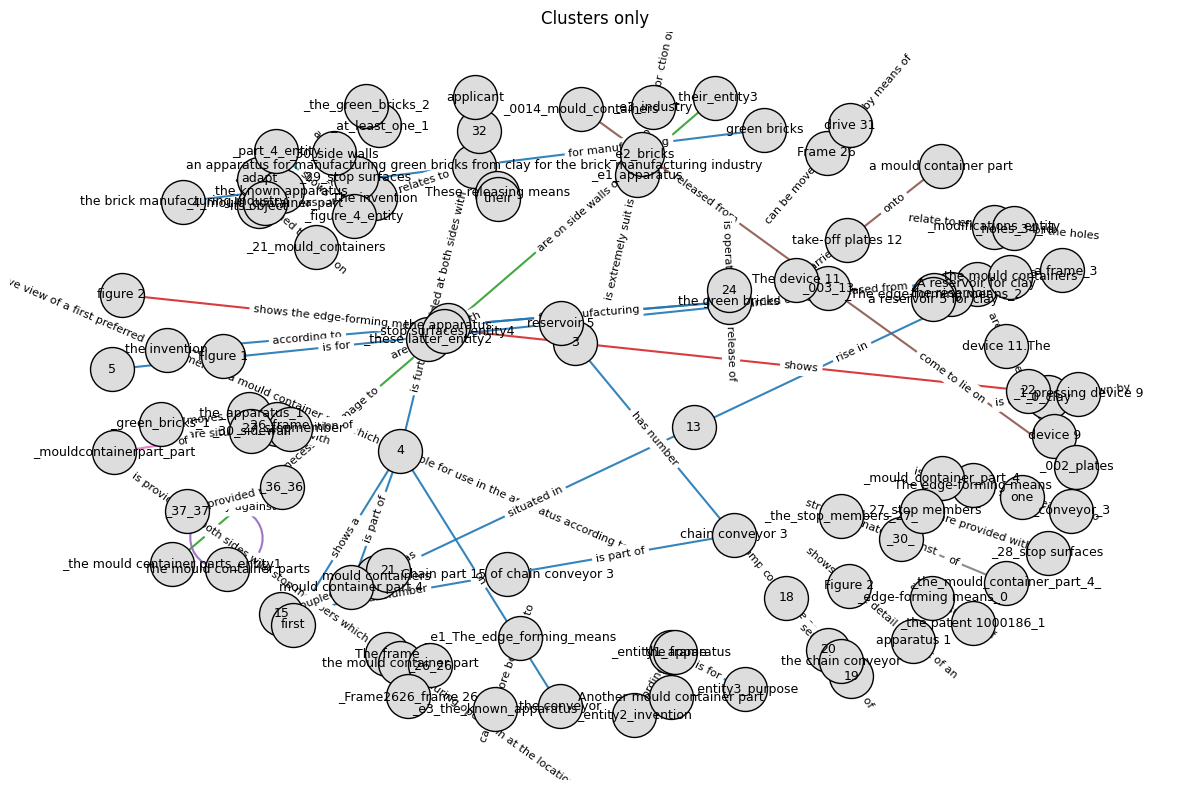

graph_clusters.html
✅ Interactive graph written to graph_clusters.html — open it in your browser.


In [29]:
visualize_matplotlib(G, title="Clusters only")
visualize_pyvis(G, out_file="graph_clusters.html")
